## Performance Summary

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../results/final_experiment_best_model_results.csv')


prevalence = 0.0807
baseline_pr = prevalence
baseline_roc = 0.5

# ==========================================
# 1. Summary Table
# ==========================================
summary = df.groupby('Model')[['Test_PR_AUC', 'Test_ROC_AUC', 'Time_Sec']].agg(['mean', 'std']).reset_index()
summary.columns = ['Model', 'PR_Mean', 'PR_Std', 'ROC_Mean', 'ROC_Std', 'Time_Mean', 'Time_Std']
summary = summary.sort_values(by='PR_Mean', ascending=False)

print("Final Model Ranking (5 Models):")
display(summary)

Final Model Ranking (5 Models):


,Model,PR_Mean,PR_Std,ROC_Mean,ROC_Std,Time_Mean,Time_Std
4,XGBoost,0.255581,0.002298,0.768683,0.002298,3352.428699,12.307503
3,SVM,0.236991,0.002428,0.756539,0.002412,1620.570981,489.741538
1,Logistic Regression,0.235271,0.001903,0.756060,0.002002,4948.927064,134.096364
2,Random Forest,0.225030,0.006739,0.747005,0.002895,1796.357732,637.457722
0,Decision Tree,0.191015,0.004198,0.707872,0.002300,135.221480,14.895267


C:\Users\admin\AppData\Local\Temp\ipykernel_1924\2662061139.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Model', y='Test_PR_AUC', data=df, order=model_order,
C:\Users\admin\AppData\Local\Temp\ipykernel_1924\2662061139.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(multiline_labels)


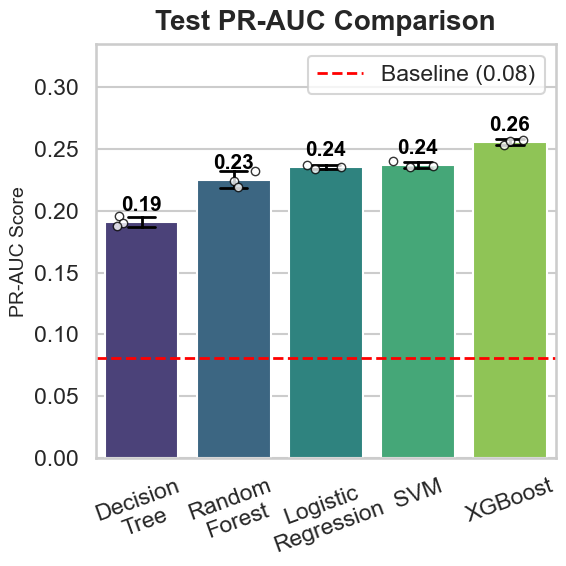

✅ PR-AUC saved to: ../figures/final_pr_auc_comparison_with_errorbar.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd


save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model_order = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'XGBoost']

multiline_labels = [
    'Decision\nTree', 
    'Random\nForest', 
    'Logistic\nRegression', 
    'SVM', 
    'XGBoost'
]

sns.set(style="whitegrid", context="talk")

# ==========================================
# 1. PR-AUC Comparison (With Error Bars)
# ==========================================
plt.figure(figsize=(6, 6))

ax1 = sns.barplot(x='Model', y='Test_PR_AUC', data=df, order=model_order, 
                  palette='viridis', capsize=0.3, alpha=1, 
                  errorbar='sd', err_kws={'linewidth': 2, 'color': 'black'}) 

sns.stripplot(x='Model', y='Test_PR_AUC', data=df, order=model_order, 
              color='white', size=6, jitter=0.28, edgecolor='black', linewidth=1, alpha=0.8)


# -------------------------------------------------------
# (Mean)
# -------------------------------------------------------
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=5, fontsize=15, color='black', fontweight='bold')

# -------------------------------------------------------
# ✅ Baseline
# -------------------------------------------------------
try:
    base_pr_val = baseline_pr
except NameError:
    base_pr_val = 0.0807 

plt.axhline(base_pr_val, color='red', linestyle='--', linewidth=2, label=f'Baseline ({base_pr_val:.2f})')

plt.title('Test PR-AUC Comparison', fontsize=20, fontweight='bold', pad=10)
plt.ylabel('PR-AUC Score', fontsize=14)
plt.xlabel('') 
ax1.set_xticklabels(multiline_labels)
plt.xticks(rotation=20)

plt.ylim(0, df['Test_PR_AUC'].max() * 1.3) 
plt.legend(loc='upper right')

save_path_pr = os.path.join(save_dir, 'final_pr_auc_comparison_with_errorbar.png')
plt.tight_layout()
plt.savefig(save_path_pr, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ PR-AUC saved to: {save_path_pr}")

C:\Users\admin\AppData\Local\Temp\ipykernel_1924\1731343756.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax1 = sns.barplot(x='Model', y='Test_PR_AUC', data=df, order=model_order,
C:\Users\admin\AppData\Local\Temp\ipykernel_1924\1731343756.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Model', y='Test_PR_AUC', data=df, order=model_order,


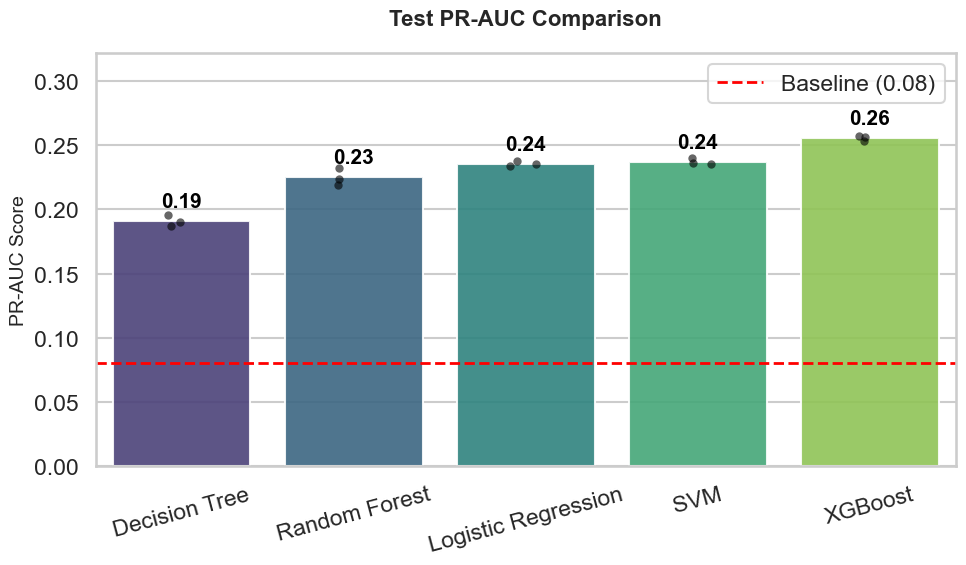

✅ PR-AUC saved to: ../figures/final_pr_auc_comparison.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd


save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"📁 Created directory: {save_dir}")

model_order = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'XGBoost']

sns.set(style="whitegrid", context="talk")

# ==========================================
# 1. PR-AUC Comparison
# ==========================================
plt.figure(figsize=(10, 6))

ax1 = sns.barplot(x='Model', y='Test_PR_AUC', data=df, order=model_order, 
                  palette='viridis', capsize=.1, alpha=0.9, ci=None)


sns.stripplot(x='Model', y='Test_PR_AUC', data=df, order=model_order, 
              color='black', size=6, jitter=0.1, alpha=0.6)


for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=7, fontsize=15, color='black', fontweight='bold')


try:
    base_pr_val = baseline_pr
except NameError:
    base_pr_val = 0.0807 

plt.axhline(base_pr_val, color='red', linestyle='--', linewidth=2, label=f'Baseline ({base_pr_val:.2f})')

plt.title('Test PR-AUC Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('PR-AUC Score', fontsize=14)
plt.xlabel('') 
plt.xticks(rotation=15)
plt.ylim(0, df['Test_PR_AUC'].max() * 1.25)
plt.legend(loc='upper right')

save_path_pr = os.path.join(save_dir, 'final_pr_auc_comparison.png')
plt.tight_layout()
plt.savefig(save_path_pr, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ PR-AUC saved to: {save_path_pr}")

C:\Users\admin\AppData\Local\Temp\ipykernel_1924\764386530.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax2 = sns.barplot(x='Model', y='Test_ROC_AUC', data=df, order=model_order,
C:\Users\admin\AppData\Local\Temp\ipykernel_1924\764386530.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Model', y='Test_ROC_AUC', data=df, order=model_order,


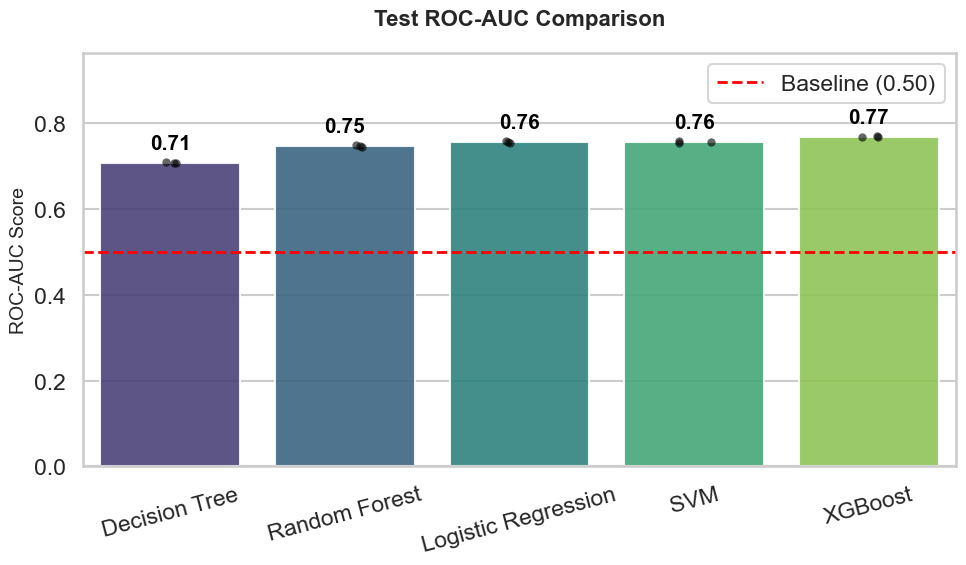

✅ ROC-AUC saved: ../figures/final_roc_auc_comparison.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd


save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model_order = ['Decision Tree', 'Random Forest', 'Logistic Regression', 'SVM', 'XGBoost']

sns.set(style="whitegrid", context="talk")


plt.figure(figsize=(10, 6))


ax2 = sns.barplot(x='Model', y='Test_ROC_AUC', data=df, order=model_order, 
                  palette='viridis', capsize=.1, alpha=0.9, ci=None)


sns.stripplot(x='Model', y='Test_ROC_AUC', data=df, order=model_order, 
              color='black', size=6, jitter=0.1, alpha=0.6)


for container in ax2.containers:

    ax2.bar_label(container, fmt='%.2f', padding=7, fontsize=15, color='black', fontweight='bold')


plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Baseline (0.50)')


plt.title('Test ROC-AUC Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('ROC-AUC Score', fontsize=14)
plt.xlabel('')
plt.xticks(rotation=15)


best_roc = df['Test_ROC_AUC'].max()

plt.ylim(0, best_roc * 1.25) 

plt.legend(loc='upper right')

# 保存
save_path_roc = os.path.join(save_dir, 'final_roc_auc_comparison.png')
plt.tight_layout()
plt.savefig(save_path_roc, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ ROC-AUC saved: {save_path_roc}")

### Decision Threshold

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import ast
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# ==========================================
# 1. Champion Model 
# ==========================================
results_path = '../results/final_experiment_best_model_results.csv'
df_results = pd.read_csv(results_path)

best_model_row = df_results[df_results['Model'] == 'XGBoost'].sort_values(by='Test_PR_AUC', ascending=False).iloc[0]

print(f" Best Model:")
print(f"   Seed: {best_model_row['Random_State']}")
print(f"   PR-AUC: {best_model_row['Test_PR_AUC']:.4f}")


raw_params = ast.literal_eval(best_model_row['Best_Params'])
final_params = {}

for key, value in raw_params.items():

    new_key = key.replace('clf__', '')
    final_params[new_key] = value

final_params['objective'] = 'binary:logistic'
final_params['eval_metric'] = 'logloss'
final_params['n_jobs'] = -1
final_params['random_state'] = int(best_model_row['Random_State']) # 确保模型内部随机性一致

print(f"Best Parameters: {final_params}")

 Best Model:
   Seed: 42
   PR-AUC: 0.2573
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_jobs': -1, 'random_state': 42}


In [14]:
df_full_application = pd.read_csv('../data/application_merged_data.csv')
df_full = df_full_application.copy()
X = df_full.drop(columns=['TARGET', 'SK_ID_CURR', 'CODE_GENDER'])
y = df_full['TARGET']

target_seed = int(best_model_row['Random_State'])

print(f"\n🔄 Re-splitting data using Winner Seed: {target_seed}...")

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=target_seed
)


🔄 Re-splitting data using Winner Seed: 42...


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import ast
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.inspection import permutation_importance


print("Loading feature metadata...")

with open('../data/feature_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

all_features = meta['all_features']

cts_features = meta['cts_features']
cts_features_log = meta['cts_features_log']
cts_features_other = meta['cts_features_other']

cat_features = meta['cat_features']
ord_features_num = meta['ord_features_num']
ord_features_str = meta['ord_features_str']
ord_features = meta['ord_features']
education_order = meta['education_order']

binary_features = meta['binary_features']
binary_features_num = meta['binary_features_num']
binary_features_str = meta['binary_features_str']

num_features_all = (
    meta['cts_features_log'] + 
    meta['cts_features_other'] + 
    meta['ord_features_num']) 

ord_encoder_unified = OrdinalEncoder(
    categories=[education_order], # 使用从 pickle 读出来的顺序
    handle_unknown='use_encoded_value', 
    unknown_value=-1
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        # 1. Nominal: OneHot
        ('nominal', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_features),
        
        # 2. Ordinal String: Encode
        ('ord_str', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), 
            ('encoder', ord_encoder_unified) 
        ]), ord_features_str),
        
        # 3. Numeric: Passthrough
        ('num_all', 'passthrough', num_features_all)
    ],
    verbose_feature_names_out=False
)


Loading feature metadata...


In [17]:
results_path = '../results/final_experiment_best_model_results.csv'
df_results = pd.read_csv(results_path)

best_model_row = df_results[df_results['Model'] == 'XGBoost'].sort_values(by='Test_PR_AUC', ascending=False).iloc[0]
target_seed = int(best_model_row['Random_State'])
params_str = best_model_row['Best_Params']

print(f"\n Champion Model Seed: {target_seed}")

try:
    raw_params = ast.literal_eval(params_str)
except ValueError:
    raw_params = ast.literal_eval(params_str.strip('"').strip("'"))

final_params = {}
for key, value in raw_params.items():
    new_key = key.replace('clf__', '')
    final_params[new_key] = value

final_params['objective'] = 'binary:logistic'
final_params['eval_metric'] = 'logloss'
final_params['n_jobs'] = -1
final_params['random_state'] = target_seed

X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=target_seed
)

final_pipeline = Pipeline([
    ('prep', tree_preprocessor),
    ('clf', xgb.XGBClassifier(**final_params))
])

print("Retraining Pipeline on Train+Val set...")
final_pipeline.fit(X_temp, y_temp)
print("Training Complete.")


 Champion Model Seed: 42
Retraining Pipeline on Train+Val set...
Training Complete.


In [20]:
from sklearn.metrics import average_precision_score, roc_auc_score

print("Checking Model Performance on Test Set...")

y_pred_proba = final_pipeline.predict_proba(X_test_final)[:, 1]

pr_auc = average_precision_score(y_test_final, y_pred_proba)
roc_auc = roc_auc_score(y_test_final, y_pred_proba)

print(f"\n✅ Test Results (Seed {target_seed}):")
print(f"   PR AUC : {pr_auc:.4f}")
print(f"   ROC AUC: {roc_auc:.4f}")
print("-" * 30)

try:
    feature_names = final_pipeline.named_steps['prep'].get_feature_names_out()
except AttributeError:
    print("use index instead")
    feature_names = [f"Feature_{i}" for i in range(final_pipeline.named_steps['clf'].n_features_in_)]

print(f"INFO: Total features after preprocessing: {len(feature_names)}")

Checking Model Performance on Test Set...

✅ Test Results (Seed 42):
   PR AUC : 0.2598
   ROC AUC: 0.7679
------------------------------
INFO: Total features after preprocessing: 258


### Search Max F2-score

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, precision_recall_curve, classification_report


fig_dir = '../figures/'
res_dir = '../results/'

for d in [fig_dir, res_dir]:
    if not os.path.exists(d):
        os.makedirs(d)

# ==========================================
# 1. Search for Optimal Threshold (Max F2-Score)
# ==========================================
print("🔍 Searching for optimal threshold based on F2 Score (Recall weighted higher)...")

# 计算 Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test_final, y_pred_proba)

# -------------------------------------------------------------------------
# Formula: (1 + beta^2) * (P * R) / ((beta^2 * P) + R)
# -------------------------------------------------------------------------
beta = 2
numerator = (1 + beta**2) * (precision[:-1] * recall[:-1])
denominator = (beta**2 * precision[:-1]) + recall[:-1]


fbeta_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

best_idx = np.argmax(fbeta_scores)
best_threshold = thresholds[best_idx]
best_f2 = fbeta_scores[best_idx]
best_recall = recall[best_idx]
best_precision = precision[best_idx]

print(f"🔥 Optimal Threshold Found (F2): {best_threshold:.4f}")
print(f"   Max F2 Score: {best_f2:.4f}")
print(f"   Recall at this threshold:    {best_recall:.4f}")
print(f"   Precision at this threshold: {best_precision:.4f}")

🔍 Searching for optimal threshold based on F2 Score (Recall weighted higher)...
🔥 Optimal Threshold Found (F2): 0.0910
   Max F2 Score: 0.4309
   Recall at this threshold:    0.6491
   Precision at this threshold: 0.1838


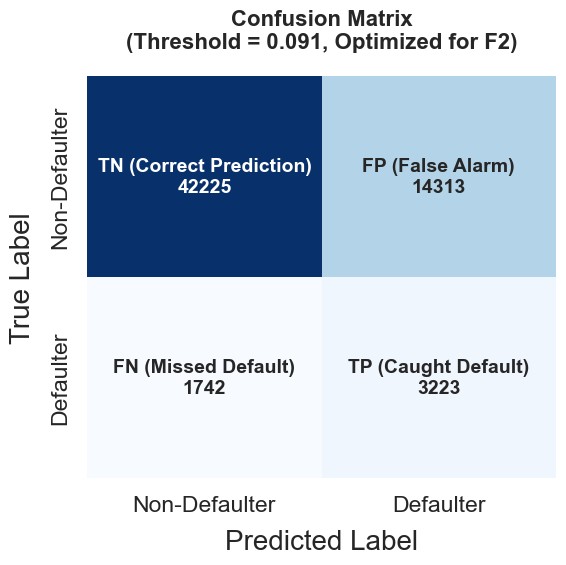

✅ Annotated Confusion Matrix saved to: ../figures/final_confusion_matrix_annotated.png


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix

y_pred_new = (y_pred_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test_final, y_pred_new)

plt.figure(figsize=(6, 6)) # 

tn, fp, fn, tp = cm.ravel()


labels = np.array([
    [f"TN (Correct Prediction)\n{tn}", f"FP (False Alarm)\n{fp}"],
    [f"FN (Missed Default)\n{fn}", f"TP (Caught Default)\n{tp}"]
])


axis_labels = ['Non-Defaulter', 'Defaulter']


sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=axis_labels, yticklabels=axis_labels,
            annot_kws={'size': 14, 'weight': 'bold'}) # 字体加粗变大


plt.title(f'Confusion Matrix\n(Threshold = {best_threshold:.3f}, Optimized for F2)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=20, labelpad=10)
plt.ylabel('True Label', fontsize=20, labelpad=10)

cm_save_path = os.path.join(fig_dir, 'final_confusion_matrix_annotated.png')
plt.tight_layout()
plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Annotated Confusion Matrix saved to: {cm_save_path}")

In [27]:
# ==========================================
# 4. Report
# ==========================================
class_report = classification_report(y_test_final, y_pred_new)

report_content = f"""
================================================
FINAL MODEL EVALUATION REPORT (XGBoost) - F2 OPTIMIZED
================================================
Seed (Random State) : {target_seed}
Optimization Target : F2-Score (Beta=2, Favor Recall)
Optimal Threshold   : {best_threshold:.6f}
Max F2 Score        : {best_f2:.6f}

Recall (Captured Defaults) : {best_recall:.4f}
Precision (Correct Alarms) : {best_precision:.4f}

Test PR-AUC         : {pr_auc:.6f}
Test ROC-AUC        : {roc_auc:.6f}

------------------------------------------------
Confusion Matrix:
{cm}
(Top-Left: TN, Top-Right: FP, Bottom-Left: FN, Bottom-Right: TP)

------------------------------------------------
Classification Report:
{class_report}
================================================
"""

print(report_content)

report_save_path = os.path.join(res_dir, 'final_model_evaluation_report_f2.txt')
with open(report_save_path, 'w') as f:
    f.write(report_content)

print(f"✅ F2-Based Report saved to: {report_save_path}")


FINAL MODEL EVALUATION REPORT (XGBoost) - F2 OPTIMIZED
Seed (Random State) : 42
Optimization Target : F2-Score (Beta=2, Favor Recall)
Optimal Threshold   : 0.090973
Max F2 Score        : 0.430928

Recall (Captured Defaults) : 0.6491
Precision (Correct Alarms) : 0.1838

Test PR-AUC         : 0.259788
Test ROC-AUC        : 0.767929

------------------------------------------------
Confusion Matrix:
[[42225 14313]
 [ 1742  3223]]
(Top-Left: TN, Top-Right: FP, Bottom-Left: FN, Bottom-Right: TP)

------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     56538
           1       0.18      0.65      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.74      0.80     61503


✅ F2-Based Report saved to: ../results/final_model_evaluation_report_f2.txt


## Feature Importance

### Global Interpretability

C:\Users\admin\AppData\Local\Temp\ipykernel_16864\200547510.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(top_n), palette='viridis')


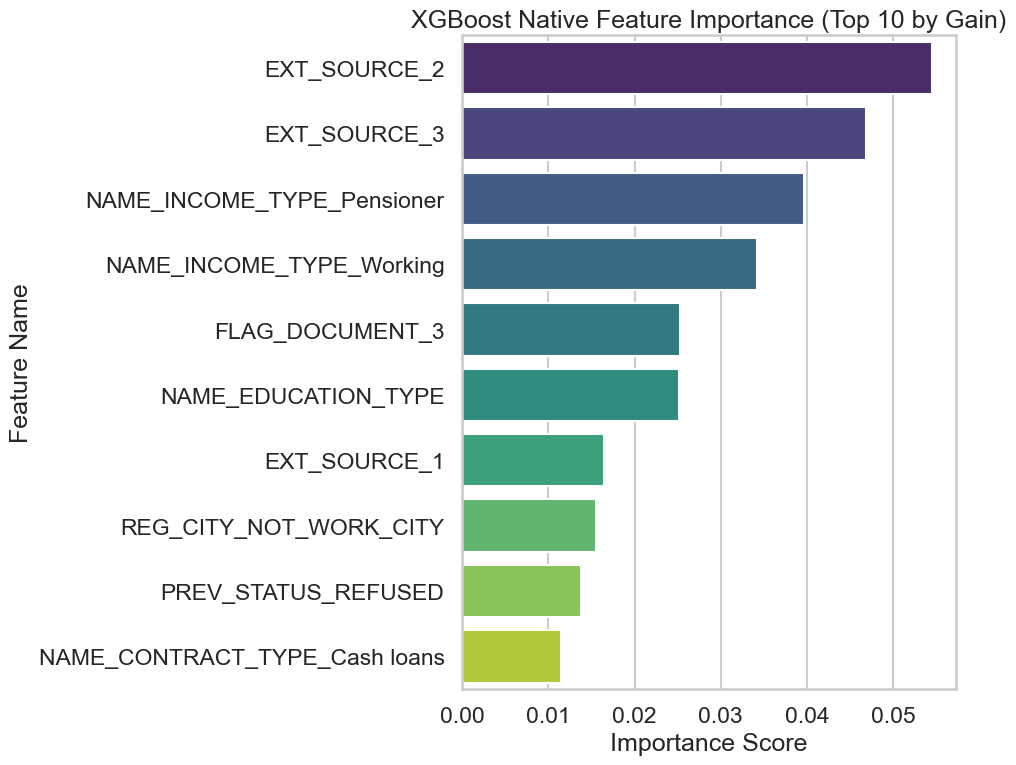


🏆 Top 10 Most Important Features (Native XGBoost):
                      Feature  Importance
                 EXT_SOURCE_2    0.054527
                 EXT_SOURCE_3    0.046873
   NAME_INCOME_TYPE_Pensioner    0.039676
     NAME_INCOME_TYPE_Working    0.034137
              FLAG_DOCUMENT_3    0.025236
          NAME_EDUCATION_TYPE    0.025184
                 EXT_SOURCE_1    0.016464
       REG_CITY_NOT_WORK_CITY    0.015593
          PREV_STATUS_REFUSED    0.013763
NAME_CONTRACT_TYPE_Cash loans    0.011502


In [ ]:
# ==========================================
# XGBoost Native Feature Importance (Gain)
# ==========================================

xgb_model = final_pipeline.named_steps['clf']

importances = xgb_model.feature_importances_


df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_n = 10

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(top_n), palette='viridis')
plt.title(f'XGBoost Native Feature Importance (Top {top_n} by Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("\n🏆 Top 10 Most Important Features (Native XGBoost):")
print(df_importance.head(10).to_string(index=False))

C:\Users\admin\AppData\Local\Temp\ipykernel_16864\1459299705.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


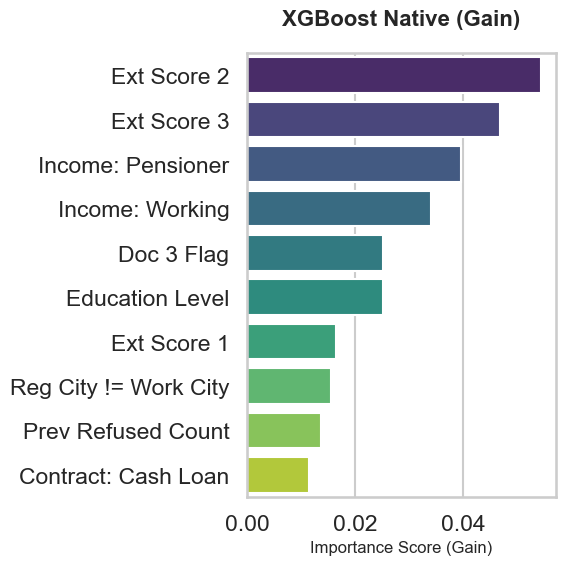

✅ XGBoost Native Importance 图已保存至: ../figures/xgboost_native_importance_ppt.png


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)


xgb_rename_map = {
    'EXT_SOURCE_1': 'Ext Score 1',
    'EXT_SOURCE_2': 'Ext Score 2',
    'EXT_SOURCE_3': 'Ext Score 3',
    'NAME_INCOME_TYPE_Pensioner': 'Income: Pensioner',
    'NAME_INCOME_TYPE_Working': 'Income: Working',
    'FLAG_DOCUMENT_3': 'Doc 3 Flag',
    'NAME_EDUCATION_TYPE': 'Education Level', # 如果是 Ordinal Encoding
    'REG_CITY_NOT_WORK_CITY': 'Reg City != Work City',
    'PREV_STATUS_REFUSED': 'Prev Refused Count',
    'NAME_CONTRACT_TYPE_Cash loans': 'Contract: Cash Loan'
}

def get_clean_name(name):

    if name in xgb_rename_map:
        return xgb_rename_map[name]
    for prefix in ['NAME_INCOME_TYPE_', 'NAME_EDUCATION_TYPE_', 'NAME_CONTRACT_TYPE_']:
        if name.startswith(prefix):
            return name.replace(prefix, '').replace('_', ' ')
            
    return name.replace('_', ' ').title()


top_n = 10
df_plot = df_importance.head(top_n).copy()


df_plot['Feature'] = df_plot['Feature'].apply(get_clean_name)


sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(6, 6))

barplot = sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_plot, 
    palette='viridis'
)


plt.title(f'XGBoost Native (Gain)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('') 

save_path = os.path.join(save_dir, 'xgboost_native_importance_ppt.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ XGBoost Native Importance saved to: {save_path}")


📊 Calculating Permutation Importance (Test Set)...


C:\Users\admin\AppData\Local\Temp\ipykernel_16864\791108156.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importance.importances_mean[sorted_idx],


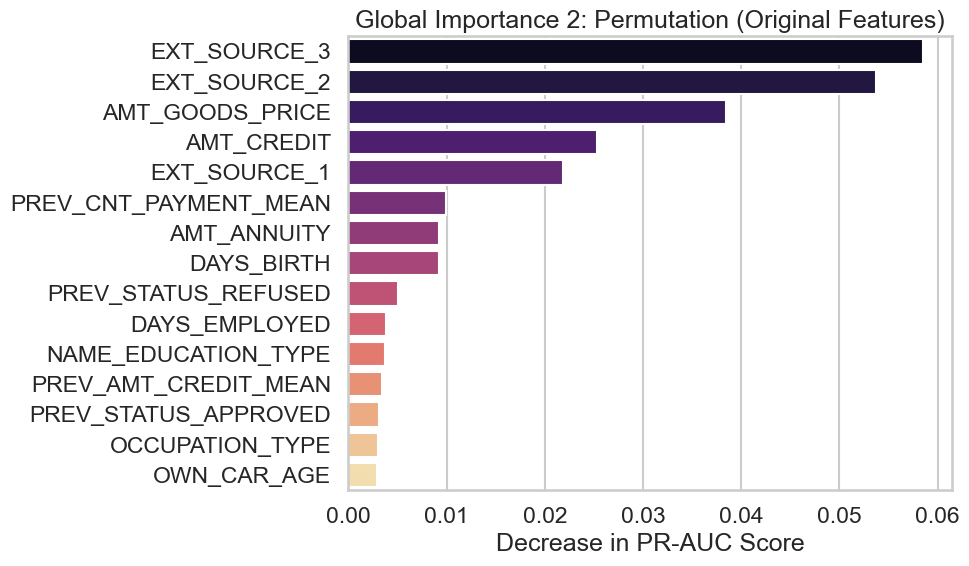


🏆 Top 10 Permutation Importance (Test Set PR-AUC Drop):
              Feature  Importance_Mean  Importance_Std
         EXT_SOURCE_3         0.058494        0.002385
         EXT_SOURCE_2         0.053718        0.001523
      AMT_GOODS_PRICE         0.038466        0.002171
           AMT_CREDIT         0.025344        0.001334
         EXT_SOURCE_1         0.021810        0.001686
PREV_CNT_PAYMENT_MEAN         0.009966        0.000896
          AMT_ANNUITY         0.009256        0.000753
           DAYS_BIRTH         0.009212        0.000412
  PREV_STATUS_REFUSED         0.005073        0.000574
        DAYS_EMPLOYED         0.003864        0.000399


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# ==========================================
# Interpretability: Permutation Importance
# ==========================================
print("\n📊 Calculating Permutation Importance (Test Set)...")

raw_feature_names = np.array(X_test_final.columns)

perm_importance = permutation_importance(
    final_pipeline, X_test_final, y_test_final, 
    n_repeats=5, random_state=target_seed, scoring='average_precision', n_jobs=-1
)

sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10] # Top 10

plt.figure(figsize=(10, 6))

sns.barplot(x=perm_importance.importances_mean[sorted_idx], 
            y=raw_feature_names[sorted_idx], palette='magma')
plt.title('Global Importance 2: Permutation (Original Features)')
plt.xlabel('Decrease in PR-AUC Score')
plt.tight_layout()
plt.show()


df_perm = pd.DataFrame({
    'Feature': raw_feature_names,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
})

df_perm = df_perm.sort_values(by='Importance_Mean', ascending=False)

print("\n🏆 Top 10 Permutation Importance (Test Set PR-AUC Drop):")
print(df_perm.head(10).to_string(index=False, float_format="%.6f"))

C:\Users\admin\AppData\Local\Temp\ipykernel_16864\2584939674.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


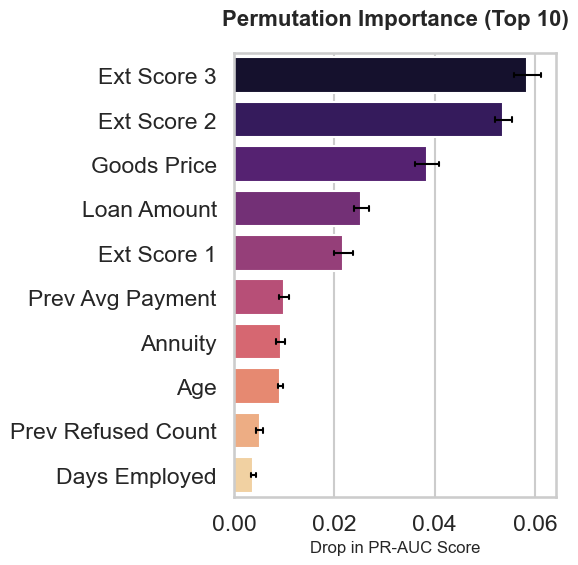

✅ Permutation 图已保存至: ../figures/permutation_importance_top10_ppt.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os


save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

feature_rename_map = {
    'EXT_SOURCE_1': 'Ext Score 1',
    'EXT_SOURCE_2': 'Ext Score 2',
    'EXT_SOURCE_3': 'Ext Score 3',
    'AMT_GOODS_PRICE': 'Goods Price',
    'AMT_CREDIT': 'Loan Amount',
    'PREV_CNT_PAYMENT_MEAN': 'Prev Avg Payment',
    'AMT_ANNUITY': 'Annuity',
    'DAYS_BIRTH': 'Age',
    'PREV_STATUS_REFUSED': 'Prev Refused Count',
    'DAYS_EMPLOYED': 'Days Employed',
}

def get_clean_name(name):

    if name in feature_rename_map:
        return feature_rename_map[name]

    return name.replace('_', ' ').title()

sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10]

top10_raw_importances = perm_importance.importances[sorted_idx]
top10_names_raw = raw_feature_names[sorted_idx]

plot_data_list = []

for i in range(len(sorted_idx)):
    feat_name_clean = get_clean_name(top10_names_raw[i])
    scores = top10_raw_importances[i]
    

    for score in scores:
        plot_data_list.append({
            'Feature': feat_name_clean,
            'Importance': score
        })


df_perm_vis = pd.DataFrame(plot_data_list)


sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(6, 6))

barplot = sns.barplot(
    data=df_perm_vis,
    x='Importance',
    y='Feature',
    palette='magma',
    errorbar='sd',
    capsize=0.1,  
    err_kws={'linewidth': 1.5, 'color': 'black'}
)


plt.title('Permutation Importance (Top 10)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Drop in PR-AUC Score', fontsize=12)
plt.ylabel('')

save_path = os.path.join(save_dir, 'permutation_importance_top10_ppt.png')
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Permutation saved to: {save_path}")


📊 Calculating SHAP Values...


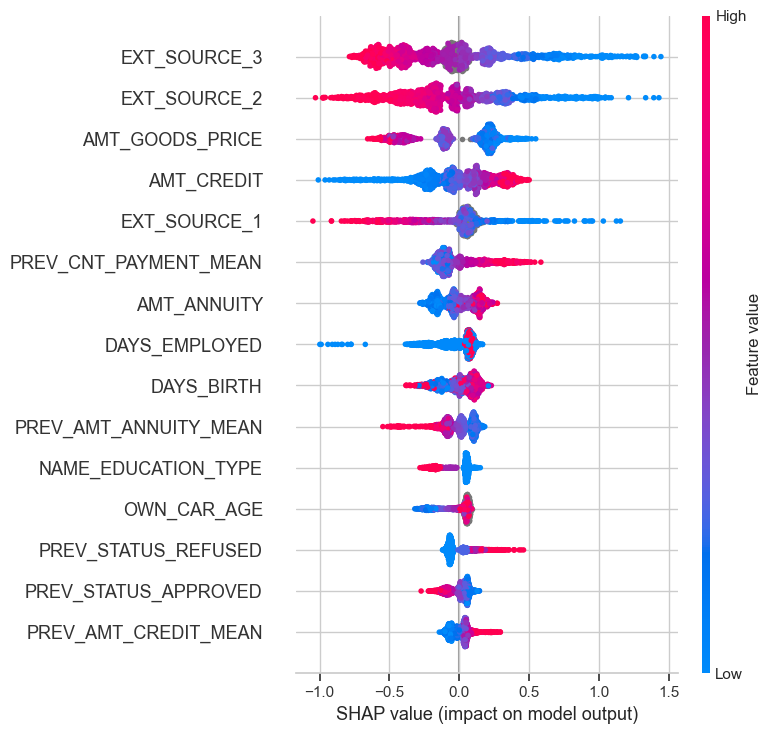


🏆 Top 10 SHAP Global Importance (Mean |SHAP|):
              Feature  Mean_Abs_SHAP
         EXT_SOURCE_3       0.345916
         EXT_SOURCE_2       0.320721
      AMT_GOODS_PRICE       0.253047
           AMT_CREDIT       0.201981
         EXT_SOURCE_1       0.170402
PREV_CNT_PAYMENT_MEAN       0.132475
          AMT_ANNUITY       0.107711
        DAYS_EMPLOYED       0.100750
           DAYS_BIRTH       0.097833
PREV_AMT_ANNUITY_MEAN       0.087811


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# ==========================================
# SHAP
# ==========================================
print("\n📊 Calculating SHAP Values...")


preprocessor = final_pipeline.named_steps['prep']
clf = final_pipeline.named_steps['clf']

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"Feature_{i}" for i in range(clf.n_features_in_)]


X_test_transformed = preprocessor.transform(X_test_final)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

if X_test_transformed_df.shape[0] > 2000:
    X_shap = X_test_transformed_df.sample(2000, random_state=target_seed)
else:
    X_shap = X_test_transformed_df

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)


plt.figure()

shap.summary_plot(shap_values, X_shap, max_display=10, show=True)


mean_abs_shap = np.abs(shap_values).mean(axis=0)

df_shap = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
})

df_shap = df_shap.sort_values(by='Mean_Abs_SHAP', ascending=False)

print("\n🏆 Top 10 SHAP Global Importance (Mean |SHAP|):")
print(df_shap.head(10).to_string(index=False, float_format="%.6f"))

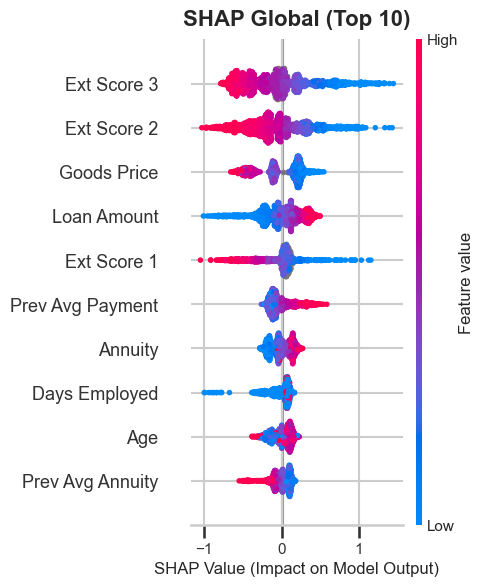

✅ PPT专用 SHAP 图已保存至: ../figures/shap_summary_ppt.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
import os

save_dir = '../figures/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)


X_shap_display = X_shap.copy()


rename_dict = {
    'AMT_GOODS_PRICE': 'Goods Price',
    'PREV_AMT_ANNUITY_MEAN': 'Prev Avg Annuity',
    'PREV_CNT_PAYMENT_MEAN': 'Prev Avg Payment',
    'EXT_SOURCE_1': 'Ext Score 1',
    'EXT_SOURCE_2': 'Ext Score 2',
    'EXT_SOURCE_3': 'Ext Score 3',
    'AMT_CREDIT': 'Loan Amount',
    'AMT_ANNUITY': 'Annuity',
    'DAYS_EMPLOYED': 'Days Employed',
    'DAYS_BIRTH': 'Age',
    'PREV_STATUS_REFUSED': 'Prev Refused Count'
}

X_shap_display.rename(columns=rename_dict, inplace=True)

plt.figure(figsize=(5, 6)) 

shap.summary_plot(
    shap_values, 
    X_shap_display, 
    max_display=10, 
    show=False,  
    plot_size=None
)

plt.title('SHAP Global (Top 10)', fontsize=16, fontweight='bold', pad=10)

plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)


save_path = os.path.join(save_dir, 'shap_summary_ppt.png')

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ PPT SHAP saved to: {save_path}")

## Local Interpretability

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

print("⚙️ Preparing for Local Interpretation...")


y_pred_proba_test = final_pipeline.predict_proba(X_test_final)[:, 1]

y_pred_label_test = (y_pred_proba_test >= best_threshold).astype(int)


df_analysis = pd.DataFrame({
    'True_Label': y_test_final.values,
    'Pred_Label': y_pred_label_test,
    'Pred_Proba': y_pred_proba_test
}, index=X_test_final.index) 


preprocessor = final_pipeline.named_steps['prep']
clf_model = final_pipeline.named_steps['clf']

try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"Feat_{i}" for i in range(clf_model.n_features_in_)]

X_test_transformed = preprocessor.transform(X_test_final)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test_final.index)


explainer = shap.TreeExplainer(clf_model)


print("\n🔍 Selecting Representative Cases...")

# Case A: True Positive 
tp_candidates = df_analysis[
    (df_analysis['True_Label'] == 1) & 
    (df_analysis['Pred_Label'] == 1) & 
    (df_analysis['Pred_Proba'] > 0.8)
]
idx_tp = tp_candidates.index[0] if len(tp_candidates) > 0 else df_analysis[(df_analysis['True_Label']==1) & (df_analysis['Pred_Label']==1)].index[0]

# Case B: False Negative 
fn_candidates = df_analysis[
    (df_analysis['True_Label'] == 1) & 
    (df_analysis['Pred_Label'] == 0) & 
    (df_analysis['Pred_Proba'] < 0.05)
]

idx_fn = fn_candidates.index[15] if len(fn_candidates) > 0 else df_analysis[(df_analysis['True_Label']==1) & (df_analysis['Pred_Label']==0)].index[9]

# Case C: False Positive 
fp_candidates = df_analysis[
    (df_analysis['True_Label'] == 0) & 
    (df_analysis['Pred_Label'] == 1) & 
    (df_analysis['Pred_Proba'] > 0.5) 
]
idx_fp = fp_candidates.index[93] if len(fp_candidates) > 0 else df_analysis[(df_analysis['True_Label']==0) & (df_analysis['Pred_Label']==1)].index[8]
# 2 31
print(f"✅ Selected Cases:")
print(f"   Case A (TP - Correct Catch): ID {idx_tp} | Proba: {df_analysis.loc[idx_tp, 'Pred_Proba']:.4f}")
print(f"   Case B (FN - Missed Fraud):  ID {idx_fn} | Proba: {df_analysis.loc[idx_fn, 'Pred_Proba']:.4f}")
print(f"   Case C (FP - False Alarm):   ID {idx_fp} | Proba: {df_analysis.loc[idx_fp, 'Pred_Proba']:.4f}")

⚙️ Preparing for Local Interpretation...

🔍 Selecting Representative Cases...
✅ Selected Cases:
   Case A (TP - Correct Catch): ID 182030 | Proba: 0.8158
   Case B (FN - Missed Fraud):  ID 233233 | Proba: 0.0355
   Case C (FP - False Alarm):   ID 61931 | Proba: 0.5288



🖼️ Generating Final Clean Plots...


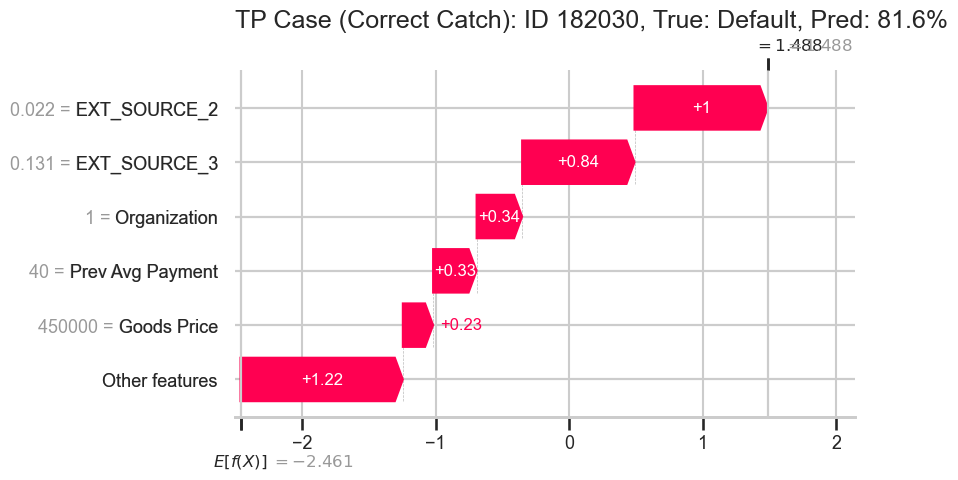

   Saved plot to ../figures/local_shap_TP_Case_Correct_Catch.png


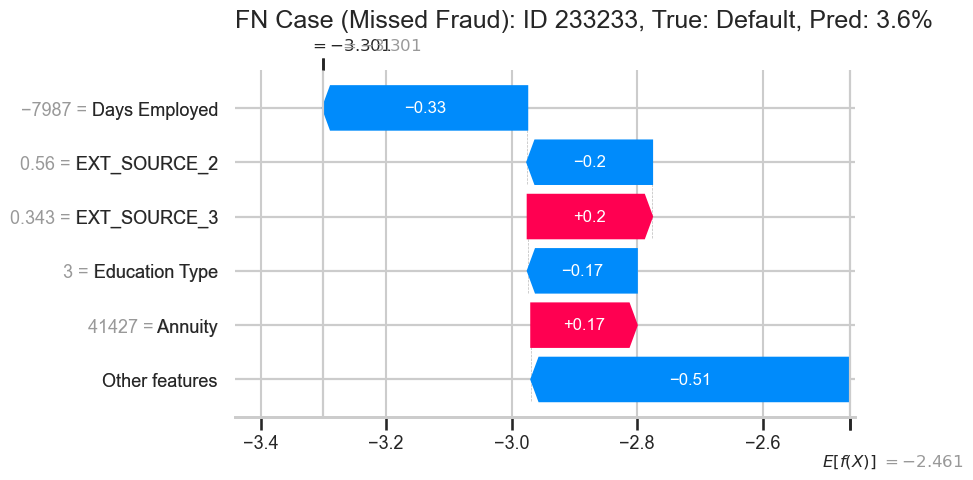

   Saved plot to ../figures/local_shap_FN_Case_Missed_Fraud.png


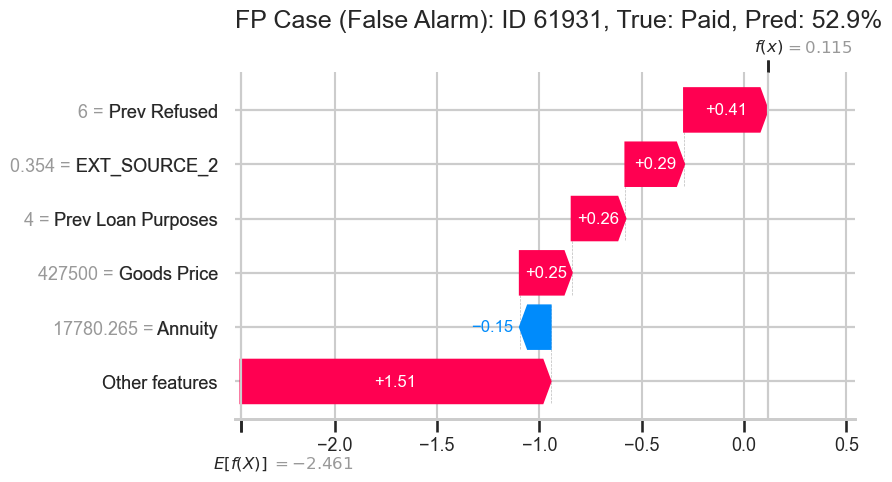

   Saved plot to ../figures/local_shap_FP_Case_False_Alarm.png


In [44]:
import matplotlib.pyplot as plt
import shap
import numpy as np


manual_map = {
    'ORGANIZATION_TYPE_Construction': 'Organization',
    'PREV_CNT_PAYMENT_MEAN': 'Prev Avg Payment',
    'AMT_GOODS_PRICE': 'Goods Price',
    'DAYS_BIRTH': 'Age',
    'DAYS_EMPLOYED': 'Days Employed',
    'AMT_CREDIT': 'Loan Amount',
    'AMT_ANNUITY': 'Annuity',
    'PREV_STATUS_REFUSED': 'Prev Refused',
    'NAME_EDUCATION_TYPE': 'Education Type',
    'CODE_GENDER_M': 'Gender: Male',
    'FLAG_OWN_CAR_Y': 'Car Owner',
    'PREV_NAME_CASH_LOAN_PURPOSE_NUNIQUE': 'Prev Loan Purposes',
    'PREV_AMT_ANNUITY_MEAN': 'Prev Avg Annuity'
}

def clean_and_save_plot(idx, case_name):
    # --- Step A:  SHAP ---
    row_transformed = X_test_df.loc[[idx]]
    shap_val_single = explainer(row_transformed)
    
    # --- Step B: feature name ---
    current_names = np.array(shap_val_single.feature_names)
    new_names = []
    for n in current_names:
        replaced = False
        for key, val in manual_map.items():
            if key in n:
                new_names.append(val)
                replaced = True
                break
        if not replaced:
            new_names.append(n)
    shap_val_single.feature_names = new_names

    # --- Step C: plt ---
    plt.figure(figsize=(20, 10)) 
    shap.plots.waterfall(shap_val_single[0], max_display=6, show=False)
    ax = plt.gca()

    labels = ax.get_yticklabels()
    new_labels = []
    for label in labels:
        text = label.get_text()
        if "other features" in text:
            new_labels.append("Other features") 
            continue
        
        for key, val in manual_map.items():
            if key in text:
                text = text.replace(key, val)
        new_labels.append(text)
    ax.set_yticklabels(new_labels, fontsize=16)

    true_label = df_analysis.loc[idx, 'True_Label']
    pred_prob = df_analysis.loc[idx, 'Pred_Proba']
    status = "Default" if true_label == 1 else "Paid"
    
    title_text = f"{case_name}: ID {idx}, True: {status}, Pred: {pred_prob:.1%}"
    
    #plt.title(title_text, fontsize=18, pad=7, loc='left', x=-0.15) 
    plt.title(title_text, fontsize=18, pad=7, loc='left') 
    
    safe_name = case_name.replace(" ", "_").replace(":", "").replace("-", "").replace("(", "").replace(")", "")
    save_path = f'../figures/local_shap_{safe_name}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"   Saved plot to {save_path}")


print("\n🖼️ Generating Final Clean Plots...")
clean_and_save_plot(idx_tp, "TP Case (Correct Catch)")
clean_and_save_plot(idx_fn, "FN Case (Missed Fraud)")
clean_and_save_plot(idx_fp, "FP Case (False Alarm)")